# Doo — Soft Voting 앙상블

Logistic Regression, Random Forest, XGBoost, SVC가 예측한 이탈 확률을 평균하여 최종 이탈 확률을 계산합니다.

- 모든 모델은 같은 Train 데이터로 다시 학습합니다.
- Validation 데이터로 개별 모델과 Voting 성능을 비교합니다.
- Test 데이터는 최종 모델 확정 전까지 사용하지 않습니다.
- 첫 실험에서는 모든 모델에 동일한 가중치 1을 사용합니다.

## 0. 실행 환경

XGBoost가 설치되어 있지 않으면 현재 노트북 커널에서 `%pip install xgboost`를 한 번 실행하고 커널을 재시작합니다.

In [4]:
from pathlib import Path
import pickle

import pandas as pd
import xgboost

from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "data" / "preprocessed").exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError("data/preprocessed 폴더를 찾을 수 없음")
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data" / "preprocessed"

X_train = pd.read_csv(DATA_DIR / "X_train.csv")
y_train = pd.read_csv(DATA_DIR / "y_train.csv")["churn"]
X_val = pd.read_csv(DATA_DIR / "X_val.csv")
y_val = pd.read_csv(DATA_DIR / "y_val.csv")["churn"]

with open(DATA_DIR / "preprocessor.pkl", "rb") as file:
    preprocessor = pickle.load(file)

print("XGBoost version:", xgboost.__version__)
print("X_train:", X_train.shape, "| X_val:", X_val.shape)
print("이탈률 - train:", y_train.mean().round(3), "| val:", y_val.mean().round(3))

XGBoost version: 3.3.0
X_train: (2592, 10) | X_val: (864, 10)
이탈률 - train: 0.494 | val: 0.494


## 1. 데이터 확인

In [5]:
display(X_train.head())
display(pd.DataFrame({
    "dtype": X_train.dtypes,
    "train_missing": X_train.isna().sum(),
    "val_missing": X_val.isna().sum(),
}))
display(y_train.value_counts().rename_axis("churn").to_frame("count"))

,net_revenue,recency_days,frequency,distinct_products,tenure_days,avg_days_between_orders,is_low_value,is_uk,has_return,recent_activity_ratio
0,-0.671757,1.614952,-0.407252,-0.671793,-0.406069,0.616805,0.0,1.0,1.0,0.0
1,-0.965400,-0.314654,-0.475206,-0.745705,-1.605762,-0.078723,0.0,1.0,0.0,0.0
2,-1.073778,0.274474,-0.475206,-0.736466,-1.245854,0.695333,0.0,1.0,0.0,0.0
3,-0.542093,-1.091619,-0.475206,-0.440820,-2.080423,-1.099580,0.0,1.0,0.0,1.0
4,-0.942516,0.641611,-0.407252,-0.487015,-0.473878,0.543887,1.0,1.0,0.0,0.0


,dtype,train_missing,val_missing
net_revenue,float64,0,0
recency_days,float64,0,0
frequency,float64,0,0
distinct_products,float64,0,0
tenure_days,float64,0,0
avg_days_between_orders,float64,0,0
is_low_value,float64,0,0
is_uk,float64,0,0
has_return,float64,0,0
recent_activity_ratio,float64,0,0


,count
churn,
0,1312
1,1280


## 2. 네 개의 기본 모델 정의

기존 개별 노트북과 같은 주요 설정을 사용합니다. Voting이 내부에서 각 모델을 복제하고 다시 학습하므로 다른 노트북의 실행 상태에 의존하지 않습니다.

In [6]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

voting_logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
)

voting_random_forest_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=1,
)

voting_xgboost_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=1,
    verbosity=0,
)

voting_svc_base_model = SVC(
    C=1.0,
    kernel="rbf",
    gamma="scale",
    class_weight="balanced",
    random_state=42,
)
voting_svc_model = CalibratedClassifierCV(
    estimator=voting_svc_base_model,
    method="sigmoid",
    cv=5,
    ensemble=False,
)

## 3. Soft Voting 학습

`voting='soft'`는 각 모델의 `churn=1` 확률을 평균합니다. `weights=[1, 1, 1, 1]`은 네 모델에 동일한 영향력을 줍니다.

In [7]:
soft_voting_model = VotingClassifier(
    estimators=[
        ("logistic", voting_logistic_model),
        ("random_forest", voting_random_forest_model),
        ("xgboost", voting_xgboost_model),
        ("svc", voting_svc_model),
    ],
    voting="soft",
    weights=[1, 1, 1, 1],
    n_jobs=-1,
)

soft_voting_model.fit(X_train, y_train)
print("Soft Voting 학습 완료")

Soft Voting 학습 완료


## 4. 개별 모델과 Soft Voting 기본 성능 비교

Voting 내부에서 학습된 네 모델과 Soft Voting을 기본 임계값 0.5에서 비교합니다.

In [8]:
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score,
)

soft_voting_fitted_models = {
    "logistic": soft_voting_model.named_estimators_["logistic"],
    "random_forest": soft_voting_model.named_estimators_["random_forest"],
    "xgboost": soft_voting_model.named_estimators_["xgboost"],
    "svc": soft_voting_model.named_estimators_["svc"],
    "soft_voting": soft_voting_model,
}

soft_voting_model_probabilities = {}
soft_voting_comparison_results = []

for model_name, fitted_model in soft_voting_fitted_models.items():
    model_pred = fitted_model.predict(X_val)
    model_proba = fitted_model.predict_proba(X_val)[:, 1]
    soft_voting_model_probabilities[model_name] = model_proba
    soft_voting_comparison_results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_val, model_pred),
        "recall": recall_score(y_val, model_pred),
        "precision": precision_score(y_val, model_pred),
        "f1": f1_score(y_val, model_pred),
        "roc_auc": roc_auc_score(y_val, model_proba),
    })

soft_voting_comparison_df = (
    pd.DataFrame(soft_voting_comparison_results)
    .sort_values("f1", ascending=False)
    .reset_index(drop=True)
)
display(soft_voting_comparison_df.style.format({
    "accuracy": "{:.3f}", "recall": "{:.3f}",
    "precision": "{:.3f}", "f1": "{:.3f}", "roc_auc": "{:.3f}",
}))

,model,accuracy,recall,precision,f1,roc_auc
0,xgboost,0.707,0.728,0.694,0.711,0.766
1,svc,0.708,0.719,0.699,0.709,0.763
2,random_forest,0.701,0.735,0.684,0.709,0.764
3,soft_voting,0.707,0.712,0.700,0.706,0.770
4,logistic,0.699,0.667,0.707,0.687,0.759


## 5. Soft Voting 임계값 비교

In [9]:
soft_voting_val_proba = soft_voting_model_probabilities["soft_voting"]
soft_voting_threshold_results = []

for threshold in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
    soft_voting_threshold_pred = (soft_voting_val_proba >= threshold).astype(int)
    soft_voting_threshold_results.append({
        "threshold": threshold,
        "recall": recall_score(y_val, soft_voting_threshold_pred),
        "precision": precision_score(y_val, soft_voting_threshold_pred, zero_division=0),
        "f1": f1_score(y_val, soft_voting_threshold_pred, zero_division=0),
        "predicted_churn_count": int(soft_voting_threshold_pred.sum()),
    })

soft_voting_threshold_df = pd.DataFrame(soft_voting_threshold_results)
display(soft_voting_threshold_df.style.format({
    "threshold": "{:.2f}", "recall": "{:.3f}",
    "precision": "{:.3f}", "f1": "{:.3f}",
}))

,threshold,recall,precision,f1,predicted_churn_count
0,0.30,0.909,0.616,0.734,630
1,0.35,0.862,0.636,0.732,579
2,0.40,0.806,0.658,0.724,523
3,0.45,0.770,0.676,0.720,487
4,0.50,0.712,0.700,0.706,434
5,0.55,0.658,0.717,0.686,392
6,0.60,0.590,0.730,0.653,345
7,0.65,0.501,0.748,0.600,286
8,0.70,0.396,0.779,0.525,217


## 6. 모델별 예측 확률 상관관계

확률 상관이 낮은 모델은 서로 다른 판단을 할 가능성이 있어 앙상블에 도움이 될 수 있습니다. 상관이 지나치게 높으면 결합 효과가 작을 수 있습니다.

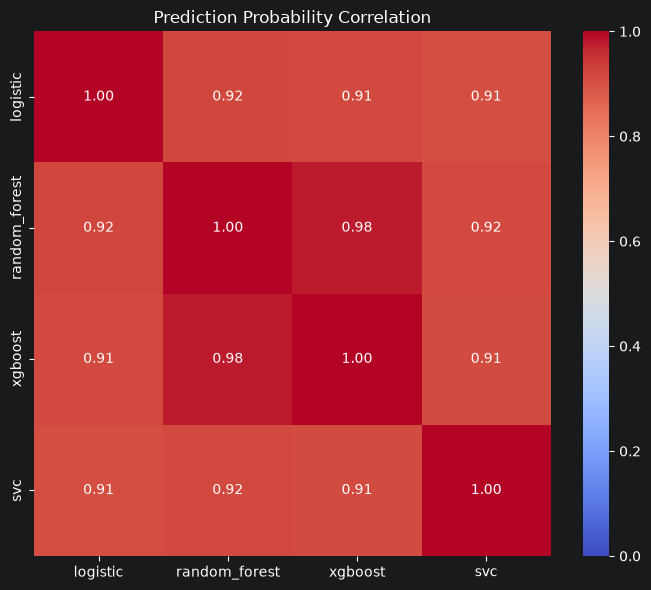

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

soft_voting_probability_df = pd.DataFrame({
    name: probability
    for name, probability in soft_voting_model_probabilities.items()
    if name != "soft_voting"
})

plt.figure(figsize=(7, 6))
sns.heatmap(soft_voting_probability_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=0, vmax=1)
plt.title("Prediction Probability Correlation")
plt.tight_layout()
plt.show()

## 7. 혼동행렬과 임계값별 성능 변화

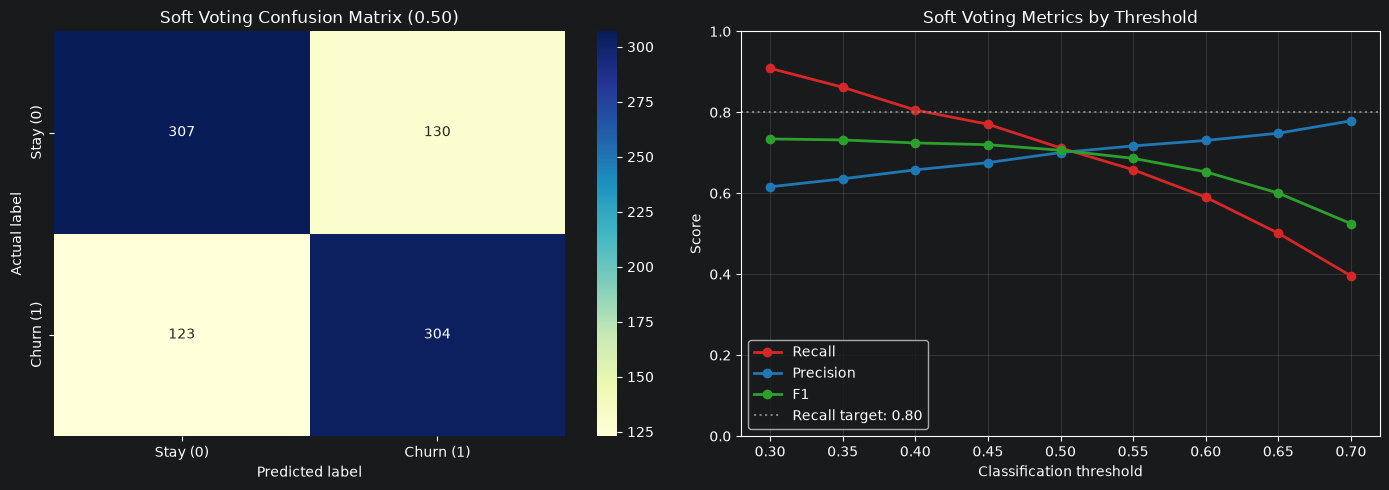

In [11]:
soft_voting_val_pred = soft_voting_model.predict(X_val)
soft_voting_confusion_matrix = confusion_matrix(y_val, soft_voting_val_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(
    soft_voting_confusion_matrix, annot=True, fmt="d", cmap="YlGnBu",
    xticklabels=["Stay (0)", "Churn (1)"],
    yticklabels=["Stay (0)", "Churn (1)"], ax=axes[0],
)
axes[0].set(xlabel="Predicted label", ylabel="Actual label", title="Soft Voting Confusion Matrix (0.50)")
for metric, color in [("recall", "tab:red"), ("precision", "tab:blue"), ("f1", "tab:green")]:
    axes[1].plot(
        soft_voting_threshold_df["threshold"], soft_voting_threshold_df[metric],
        marker="o", linewidth=2, color=color,
        label=metric.upper() if metric == "f1" else metric.title(),
    )
axes[1].axhline(0.80, color="gray", linestyle=":", label="Recall target: 0.80")
axes[1].set(xlabel="Classification threshold", ylabel="Score", title="Soft Voting Metrics by Threshold", ylim=(0, 1))
axes[1].grid(alpha=0.25)
axes[1].legend()
plt.tight_layout()
plt.show()

## 8. ROC Curve와 Precision–Recall Curve 비교

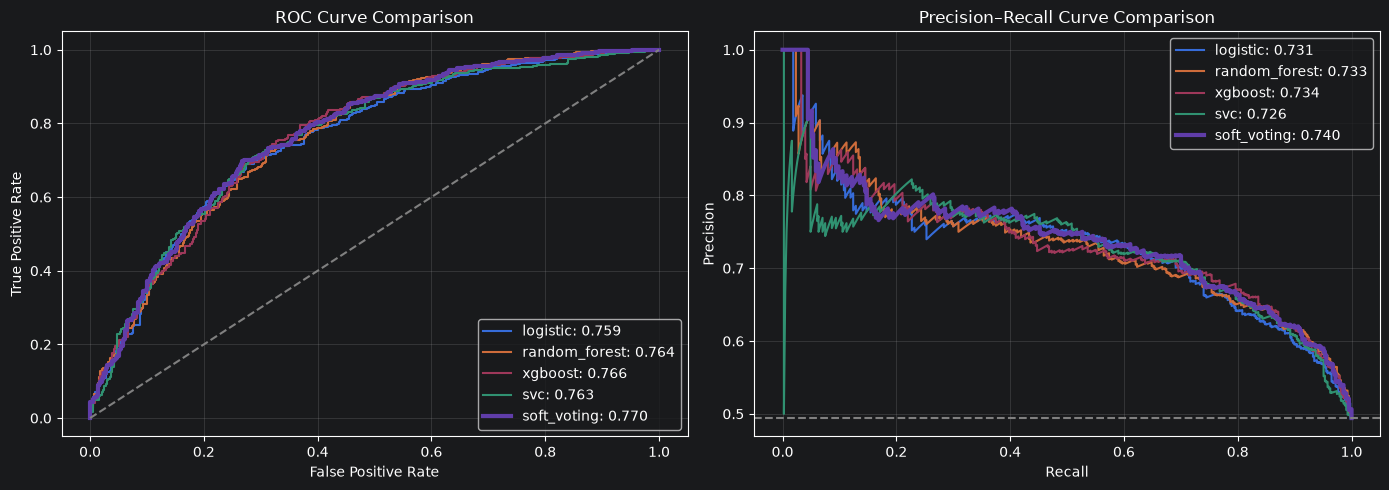

In [12]:
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for model_name, model_proba in soft_voting_model_probabilities.items():
    model_fpr, model_tpr, _ = roc_curve(y_val, model_proba)
    model_roc_auc = roc_auc_score(y_val, model_proba)
    model_precision, model_recall, _ = precision_recall_curve(y_val, model_proba)
    model_ap = average_precision_score(y_val, model_proba)
    line_width = 3 if model_name == "soft_voting" else 1.5
    axes[0].plot(model_fpr, model_tpr, linewidth=line_width, label=f"{model_name}: {model_roc_auc:.3f}")
    axes[1].plot(model_recall, model_precision, linewidth=line_width, label=f"{model_name}: {model_ap:.3f}")

axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC Curve Comparison")
axes[1].axhline(y_val.mean(), linestyle="--", color="gray")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision–Recall Curve Comparison")
for axis in axes:
    axis.legend()
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 9. 실험 결과 기록

Recall 0.80 이상 후보 중 F1-score가 가장 높은 임계값을 선택합니다.

In [13]:
soft_voting_candidates = soft_voting_threshold_df[soft_voting_threshold_df["recall"] >= 0.80]
if soft_voting_candidates.empty:
    print("Recall 0.80 이상인 임계값 후보가 없습니다.")
else:
    soft_voting_best_candidate = soft_voting_candidates.loc[soft_voting_candidates["f1"].idxmax()]
    display(soft_voting_best_candidate.to_frame("selected_value"))

,selected_value
threshold,0.300000
recall,0.908665
precision,0.615873
f1,0.734153
predicted_churn_count,630.000000


## 10. 모델 구성 및 평가 기준 설명

Soft Voting은 여러 모델의 최종 분류 결과가 아니라 `predict_proba()`로 얻은 이탈 확률을 평균하는 앙상블이다. 선형 모델, Bagging, Boosting, 커널 모델처럼 학습 방식이 다른 모델을 결합해 한 모델의 오류를 다른 모델이 보완하는 것을 목표로 한다.

### 구성 원칙

- 네 모델을 동일한 Train 데이터로 다시 학습해 공정한 조건을 유지했다.
- SVC는 deprecated된 `probability=True` 대신 `CalibratedClassifierCV`로 확률을 보정했다.
- 첫 베이스라인은 `weights=[1, 1, 1, 1]`로 동일 가중치를 사용한다. Validation 결과만 보고 가중치를 지나치게 반복 조정하면 과적합될 수 있으므로 가중치 튜닝은 Train 교차검증으로 수행해야 한다.
- 내부 모델의 `n_jobs=1`, Voting의 `n_jobs=-1` 설정으로 중첩 병렬 실행을 줄였다.

### 평가 기준

기본 임계값과 임계값별 Recall, Precision, F1-score를 확인하고 ROC-AUC 및 Precision–Recall Curve로 개별 모델과 Voting을 비교한다. 모델별 예측 확률 상관관계는 모델들이 서로 다른 정보를 제공하는지 확인하기 위한 참고 지표다. Soft Voting이 단일 모델보다 반드시 좋은 것은 아니므로, 동일한 Validation 기준에서 실제로 개선됐을 때만 최종 후보로 유지한다. Test 데이터는 최종 모델 확정 전까지 사용하지 않는다.